# V14 – OT1 + OT2 Weight Variants

**Hypothesis:** The V9 winner (Grandfamilien OT1 only, no threshold) is good but uses only the
coarsest flavour level. Adding OT2 (subfamilies) at a reduced weight might enrich the feature
space just enough to pull recipes apart more clearly — without introducing the potency-collapse
problem seen in the V13 threshold experiments.

**Setup:** No threshold. Feature space = OT1 (weight 1.0) + OT2 (weight α), scanning α.

| Variant | OT1 weight | OT2 weight | Note |
|---------|-----------|-----------|------|
| V14-A | 1.0 | 0.0 | Baseline = V9 winner |
| V14-B | 1.0 | 0.10 | Tiny OT2 hint |
| V14-C | 1.0 | 0.25 | Quarter OT2 |
| V14-D | 1.0 | 0.50 | Half OT2 |
| V14-E | 1.0 | 0.75 | Three-quarter OT2 |
| V14-F | 1.0 | 1.00 | Equal OT1+OT2 |
| V14-G | 0.0 | 1.00 | OT2 only (control) |
| V14-H | 1.0 | 0.33 | V7 subfamilien ratio (pos_weight(2,3)) |

All variants: FAISS k-means, PCA 2D, no threshold.

In [1]:
import sys, os
PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), '..'))
sys.path.insert(0, PROJECT_ROOT)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import matplotlib.gridspec as gridspec
import warnings
warnings.filterwarnings('ignore')

from sklearn.metrics import silhouette_score
from sklearn.preprocessing import normalize
from sklearn.decomposition import PCA

try:
    import faiss
    FAISS_AVAILABLE = True
    print('FAISS available ✓')
except ImportError:
    FAISS_AVAILABLE = False
    print('FAISS not available – cannot run this notebook')

%matplotlib inline
plt.rcParams['figure.dpi'] = 120
print('Libraries loaded ✓')

FAISS available ✓
Libraries loaded ✓


## 1. Data Loading & Preprocessing (same as V9/V13)

In [2]:
DATA_PATH     = '../data/gold/Versuchsdaten_3_1.csv'
IGNORE_PATH   = '../data/gold/ignone_substances.csv'
CAS_PATH      = '../data/gold/CAS Nummern.csv'
OUTPUT_DIR    = '../outputs'
REFERENCE_IMG = '../outputs/reference_pca_handdrawn.png'
os.makedirs(OUTPUT_DIR, exist_ok=True)

df_raw = pd.read_csv(DATA_PATH)
ign    = pd.read_csv(IGNORE_PATH)
cas    = pd.read_csv(CAS_PATH, header=13)

print(f'Versuchsdaten_3_1: {df_raw.shape[0]} rows, {df_raw["Rez.-Nr."].nunique()} recipes')

Versuchsdaten_3_1: 658 rows, 24 recipes


In [3]:
# Ignore list + renormalise (identical to V9)
ign_cas = ign[['Ident']].merge(
    cas[['Ident.', 'CAS-Nr.: - Hinweis 1']].rename(columns={'Ident.': 'Ident'}),
    on='Ident', how='left'
)
cas_to_ignore   = set(ign_cas['CAS-Nr.: - Hinweis 1'].dropna().astype(str).str.strip())
names_to_ignore = {str(n).lower().strip() for n in ign['Name']}

df = df_raw.copy()
df['_cas'] = df['CAS-Nr.: - Hinweis 1'].astype(str).str.strip()
df.loc[df['_cas'].isin(cas_to_ignore), 'Totalmenge'] = 0.0
df.drop(columns='_cas', inplace=True)
df.loc[df['Name'].str.lower().str.strip().isin(names_to_ignore), 'Totalmenge'] = 0.0

per_recipe_total = df.groupby('Rez.-Nr.')['Totalmenge'].transform('sum')
df['Totalmenge'] = np.where(per_recipe_total > 0,
                            df['Totalmenge'] / per_recipe_total,
                            df['Totalmenge'])
assert df.groupby('Rez.-Nr.')['Totalmenge'].sum().round(6).eq(1.0).all()
print('Preprocessing done ✓')

Preprocessing done ✓


## 2. Helper Functions

In [4]:
OT1 = 'Odour Type 1 FlavourWheel'
OT2 = 'Odour Type 2 Flavour Wheel'
OT3 = 'Odour Type 3 Flavour Wheel'
OUTLIER_RECIPES = ['185.028', '188.740']

def norm_term(term):
    if pd.isna(term) or not isinstance(term, str):
        return None
    t = term.lower().strip().replace('"', '').replace("'", '').rstrip('.,;:')
    return t if len(t) >= 2 else None

def build_vocabulary(df, feature_cols):
    all_terms = set()
    for col in feature_cols:
        if col in df.columns:
            for t in df[col].dropna().map(norm_term):
                if t:
                    all_terms.add(t)
    return sorted(all_terms)

def build_recipe_vectors(df, recipes, feature_cols_weighted):
    """
    Build L2-normalised recipe vectors. No threshold – pure Totalmenge weighting.
    feature_cols_weighted: list of (column_name, weight) tuples.
    """
    feature_cols = [col for col, _ in feature_cols_weighted]
    vocab        = build_vocabulary(df, feature_cols)
    vocab_to_idx = {t: i for i, t in enumerate(vocab)}
    n_recipes    = len(recipes)
    n_feat       = len(vocab)
    vectors      = np.zeros((n_recipes, n_feat), dtype=np.float64)

    for r_idx, recipe in enumerate(recipes):
        rows = df[df['Rez.-Nr.'] == recipe]
        for _, row in rows.iterrows():
            qty = float(row['Totalmenge'])
            if qty <= 0:
                continue
            for col, col_weight in feature_cols_weighted:
                if col not in df.columns:
                    continue
                term = norm_term(row.get(col))
                if term and term in vocab_to_idx:
                    vectors[r_idx, vocab_to_idx[term]] += col_weight * qty

    return vocab, normalize(vectors)

def run_faiss_clustering(recipe_vecs, k_range=(3, 12)):
    vectors_f32 = np.ascontiguousarray(recipe_vecs.astype('float32'))
    n_v, d      = vectors_f32.shape
    best_k, best_score  = k_range[0], -1
    best_labels         = None
    for k in range(k_range[0], min(k_range[1] + 1, n_v)):
        km = faiss.Kmeans(d, k, niter=50, verbose=False, seed=42)
        km.train(vectors_f32)
        _, lbl = km.index.search(vectors_f32, 1)
        lbl = lbl.flatten()
        if len(set(lbl)) > 1:
            s = silhouette_score(vectors_f32, lbl)
            if s > best_score:
                best_score  = s
                best_k      = k
                best_labels = lbl.copy()
    return best_labels, best_k, best_score

def generate_cluster_names(cluster_labels, recipe_vecs, vocab, top_n=3):
    unique_labels = sorted(set(cluster_labels))
    global_cen    = recipe_vecs.mean(axis=0)
    centroids     = {l: recipe_vecs[cluster_labels == l].mean(axis=0)
                     for l in unique_labels}
    names = {}
    for label in unique_labels:
        cen     = centroids[label]
        dist    = cen - global_cen * 0.8
        top_idx = np.argsort(dist)[-6:][::-1]
        terms   = [vocab[i].capitalize()
                   for i in top_idx if dist[i] > 0 and cen[i] > 0.05][:top_n]
        if len(terms) < 2:
            terms = [vocab[i].capitalize()
                     for i in np.argsort(cen)[-top_n:][::-1]]
        names[label] = '-'.join(terms[:top_n])
    return names

print('Helpers defined ✓')

Helpers defined ✓


## 3. Define Variants

In [5]:
VARIANTS = [
    {'id': 'A', 'ot1': 1.0, 'ot2': 0.00, 'label': 'A: OT1×1.0  OT2×0.00  [V9 baseline]'},
    {'id': 'B', 'ot1': 1.0, 'ot2': 0.10, 'label': 'B: OT1×1.0  OT2×0.10'},
    {'id': 'C', 'ot1': 1.0, 'ot2': 0.25, 'label': 'C: OT1×1.0  OT2×0.25'},
    {'id': 'D', 'ot1': 1.0, 'ot2': 0.50, 'label': 'D: OT1×1.0  OT2×0.50'},
    {'id': 'E', 'ot1': 1.0, 'ot2': 0.75, 'label': 'E: OT1×1.0  OT2×0.75'},
    {'id': 'F', 'ot1': 1.0, 'ot2': 1.00, 'label': 'F: OT1×1.0  OT2×1.00  (equal)'},
    {'id': 'G', 'ot1': 0.0, 'ot2': 1.00, 'label': 'G: OT1×0.0  OT2×1.00  (OT2 only)'},
    {'id': 'H', 'ot1': 1.0, 'ot2': 0.33, 'label': 'H: OT1×1.0  OT2×0.33  (V7 pos_weight ratio)'},
]

print(f'{len(VARIANTS)} variants defined:')
for v in VARIANTS:
    print(f'  V14-{v["id"]}: {v["label"]}')

8 variants defined:
  V14-A: A: OT1×1.0  OT2×0.00  [V9 baseline]
  V14-B: B: OT1×1.0  OT2×0.10
  V14-C: C: OT1×1.0  OT2×0.25
  V14-D: D: OT1×1.0  OT2×0.50
  V14-E: E: OT1×1.0  OT2×0.75
  V14-F: F: OT1×1.0  OT2×1.00  (equal)
  V14-G: G: OT1×0.0  OT2×1.00  (OT2 only)
  V14-H: H: OT1×1.0  OT2×0.33  (V7 pos_weight ratio)


## 4. Run All Variants

In [6]:
recipes = df['Rez.-Nr.'].unique().tolist()
print(f'Total recipes: {len(recipes)}\n')

results = {}

for v in VARIANTS:
    vid  = v['id']
    fcw  = [(OT1, v['ot1'])]
    if v['ot2'] > 0:
        fcw.append((OT2, v['ot2']))

    vocab, vecs = build_recipe_vectors(df, recipes, fcw)
    labels, best_k, best_score = run_faiss_clustering(vecs)
    cnames = generate_cluster_names(labels, vecs, vocab)

    pca_obj  = PCA(n_components=2)
    coords   = pca_obj.fit_transform(vecs)
    var_expl = pca_obj.explained_variance_ratio_ * 100

    results[vid] = {
        'label'     : v['label'],
        'ot1'       : v['ot1'],
        'ot2'       : v['ot2'],
        'vocab'     : vocab,
        'vecs'      : vecs,
        'labels'    : labels,
        'k'         : best_k,
        'score'     : best_score,
        'cnames'    : cnames,
        'pca_coords': coords,
        'var_expl'  : var_expl,
        'vocab_size': len(vocab),
    }

    print(f'V14-{vid}: {v["label"]}')
    print(f'  vocab={len(vocab)}, k={best_k}, sil={best_score:.4f}, '
          f'PCA F1={var_expl[0]:.1f}% F2={var_expl[1]:.1f}% total={sum(var_expl):.1f}%')
    for cl in sorted(set(labels)):
        recs = [r for r, m in zip(recipes, labels == cl) if m]
        flag = ' ⚠' if any(r in OUTLIER_RECIPES for r in recs) else ''
        print(f'    C{cl} ({cnames[cl]}): {recs}{flag}')
    print()

Total recipes: 24

V14-A: A: OT1×1.0  OT2×0.00  [V9 baseline]
  vocab=9, k=3, sil=0.2893, PCA F1=41.5% F2=29.5% total=71.0%
    C0 (Fruity-Unpleasant-Dairy): ['187.796P', '185.507P', '187.894P', '185.267', '185.471', '187.886P', '187.787P', '185.090P', '185.294']
    C1 (Warm-Fruity-Fresh): ['185.309P', '186.277P', '185.237H', '187.694P', '188.740P', '187.800P', '187.916P']
    C2 (Green-Warm-Fresh): ['185.028', '185.091', '186.190P', '187.507P', '188.412P', '185.382P', '187.657P', '185.675P'] ⚠

V14-B: B: OT1×1.0  OT2×0.10
  vocab=11, k=6, sil=0.3293, PCA F1=41.9% F2=30.6% total=72.6%
    C0 (Fruity-Unpleasant-Dairy): ['187.796P', '185.507P', '185.267', '185.471', '187.886P', '187.787P', '185.090P', '185.294']
    C1 (Warm-Fruity-Floral): ['185.309P', '186.277P', '185.237H', '187.694P']
    C2 (Green-Fruity-Dairy): ['187.894P', '185.091', '187.507P', '188.412P', '185.382P', '187.657P']
    C3 (Warm-Fruity): ['187.800P', '187.916P']
    C4 (Green-Warm): ['186.190P', '185.675P']
    C5 

WARNING clustering 24 points to 3 centroids: please provide at least 117 training points
WARNING clustering 24 points to 4 centroids: please provide at least 156 training points
WARNING clustering 24 points to 5 centroids: please provide at least 195 training points
WARNING clustering 24 points to 6 centroids: please provide at least 234 training points
WARNING clustering 24 points to 7 centroids: please provide at least 273 training points
WARNING clustering 24 points to 8 centroids: please provide at least 312 training points
WARNING clustering 24 points to 9 centroids: please provide at least 351 training points
WARNING clustering 24 points to 10 centroids: please provide at least 390 training points
WARNING clustering 24 points to 11 centroids: please provide at least 429 training points
WARNING clustering 24 points to 12 centroids: please provide at least 468 training points
WARNING clustering 24 points to 3 centroids: please provide at least 117 training points
WARNING clustering

V14-F: F: OT1×1.0  OT2×1.00  (equal)
  vocab=11, k=9, sil=0.2642, PCA F1=40.0% F2=31.5% total=71.5%
    C0 (Fresh-Green-Unpleasant): ['185.028', '188.412P', '187.657P', '185.294'] ⚠
    C1 (Warm-Woody-Fruity): ['186.277P', '185.237H']
    C2 (Green-Fresh-Warm): ['185.091', '185.382P', '185.675P']
    C3 (Warm-Woody-Fruity): ['187.800P', '187.916P']
    C4 (Balsamic-Green-Fresh): ['186.190P']
    C5 (Fruity-Fresh-Exotic): ['187.886P', '187.787P', '188.740P']
    C6 (Fruity-Exotic-Fresh): ['185.471']
    C7 (Warm-Fruity-Fresh): ['185.507P', '187.894P', '185.309P', '187.507P', '187.694P']
    C8 (Fruity-Unpleasant-Exotic): ['187.796P', '185.267', '185.090P']

V14-G: G: OT1×0.0  OT2×1.00  (OT2 only)
  vocab=11, k=10, sil=0.2463, PCA F1=38.9% F2=22.1% total=61.0%
    C0 (Unpleasant-Fresh-Warm): ['185.028', '187.657P', '185.294'] ⚠
    C1 (Woody-Unpleasant-Fruity): ['185.309P', '186.277P', '185.237H']
    C2 (Fresh-Fruity-Balsamic): ['187.886P', '185.091']
    C3 (Woody-Fruity-Balsamic): ['1

WARNING clustering 24 points to 5 centroids: please provide at least 195 training points
WARNING clustering 24 points to 6 centroids: please provide at least 234 training points
WARNING clustering 24 points to 7 centroids: please provide at least 273 training points
WARNING clustering 24 points to 8 centroids: please provide at least 312 training points
WARNING clustering 24 points to 9 centroids: please provide at least 351 training points
WARNING clustering 24 points to 10 centroids: please provide at least 390 training points
WARNING clustering 24 points to 11 centroids: please provide at least 429 training points
WARNING clustering 24 points to 12 centroids: please provide at least 468 training points
WARNING clustering 24 points to 3 centroids: please provide at least 117 training points
WARNING clustering 24 points to 4 centroids: please provide at least 156 training points
WARNING clustering 24 points to 5 centroids: please provide at least 195 training points
WARNING clustering

## 5. Visual Comparison – All Variants + Reference

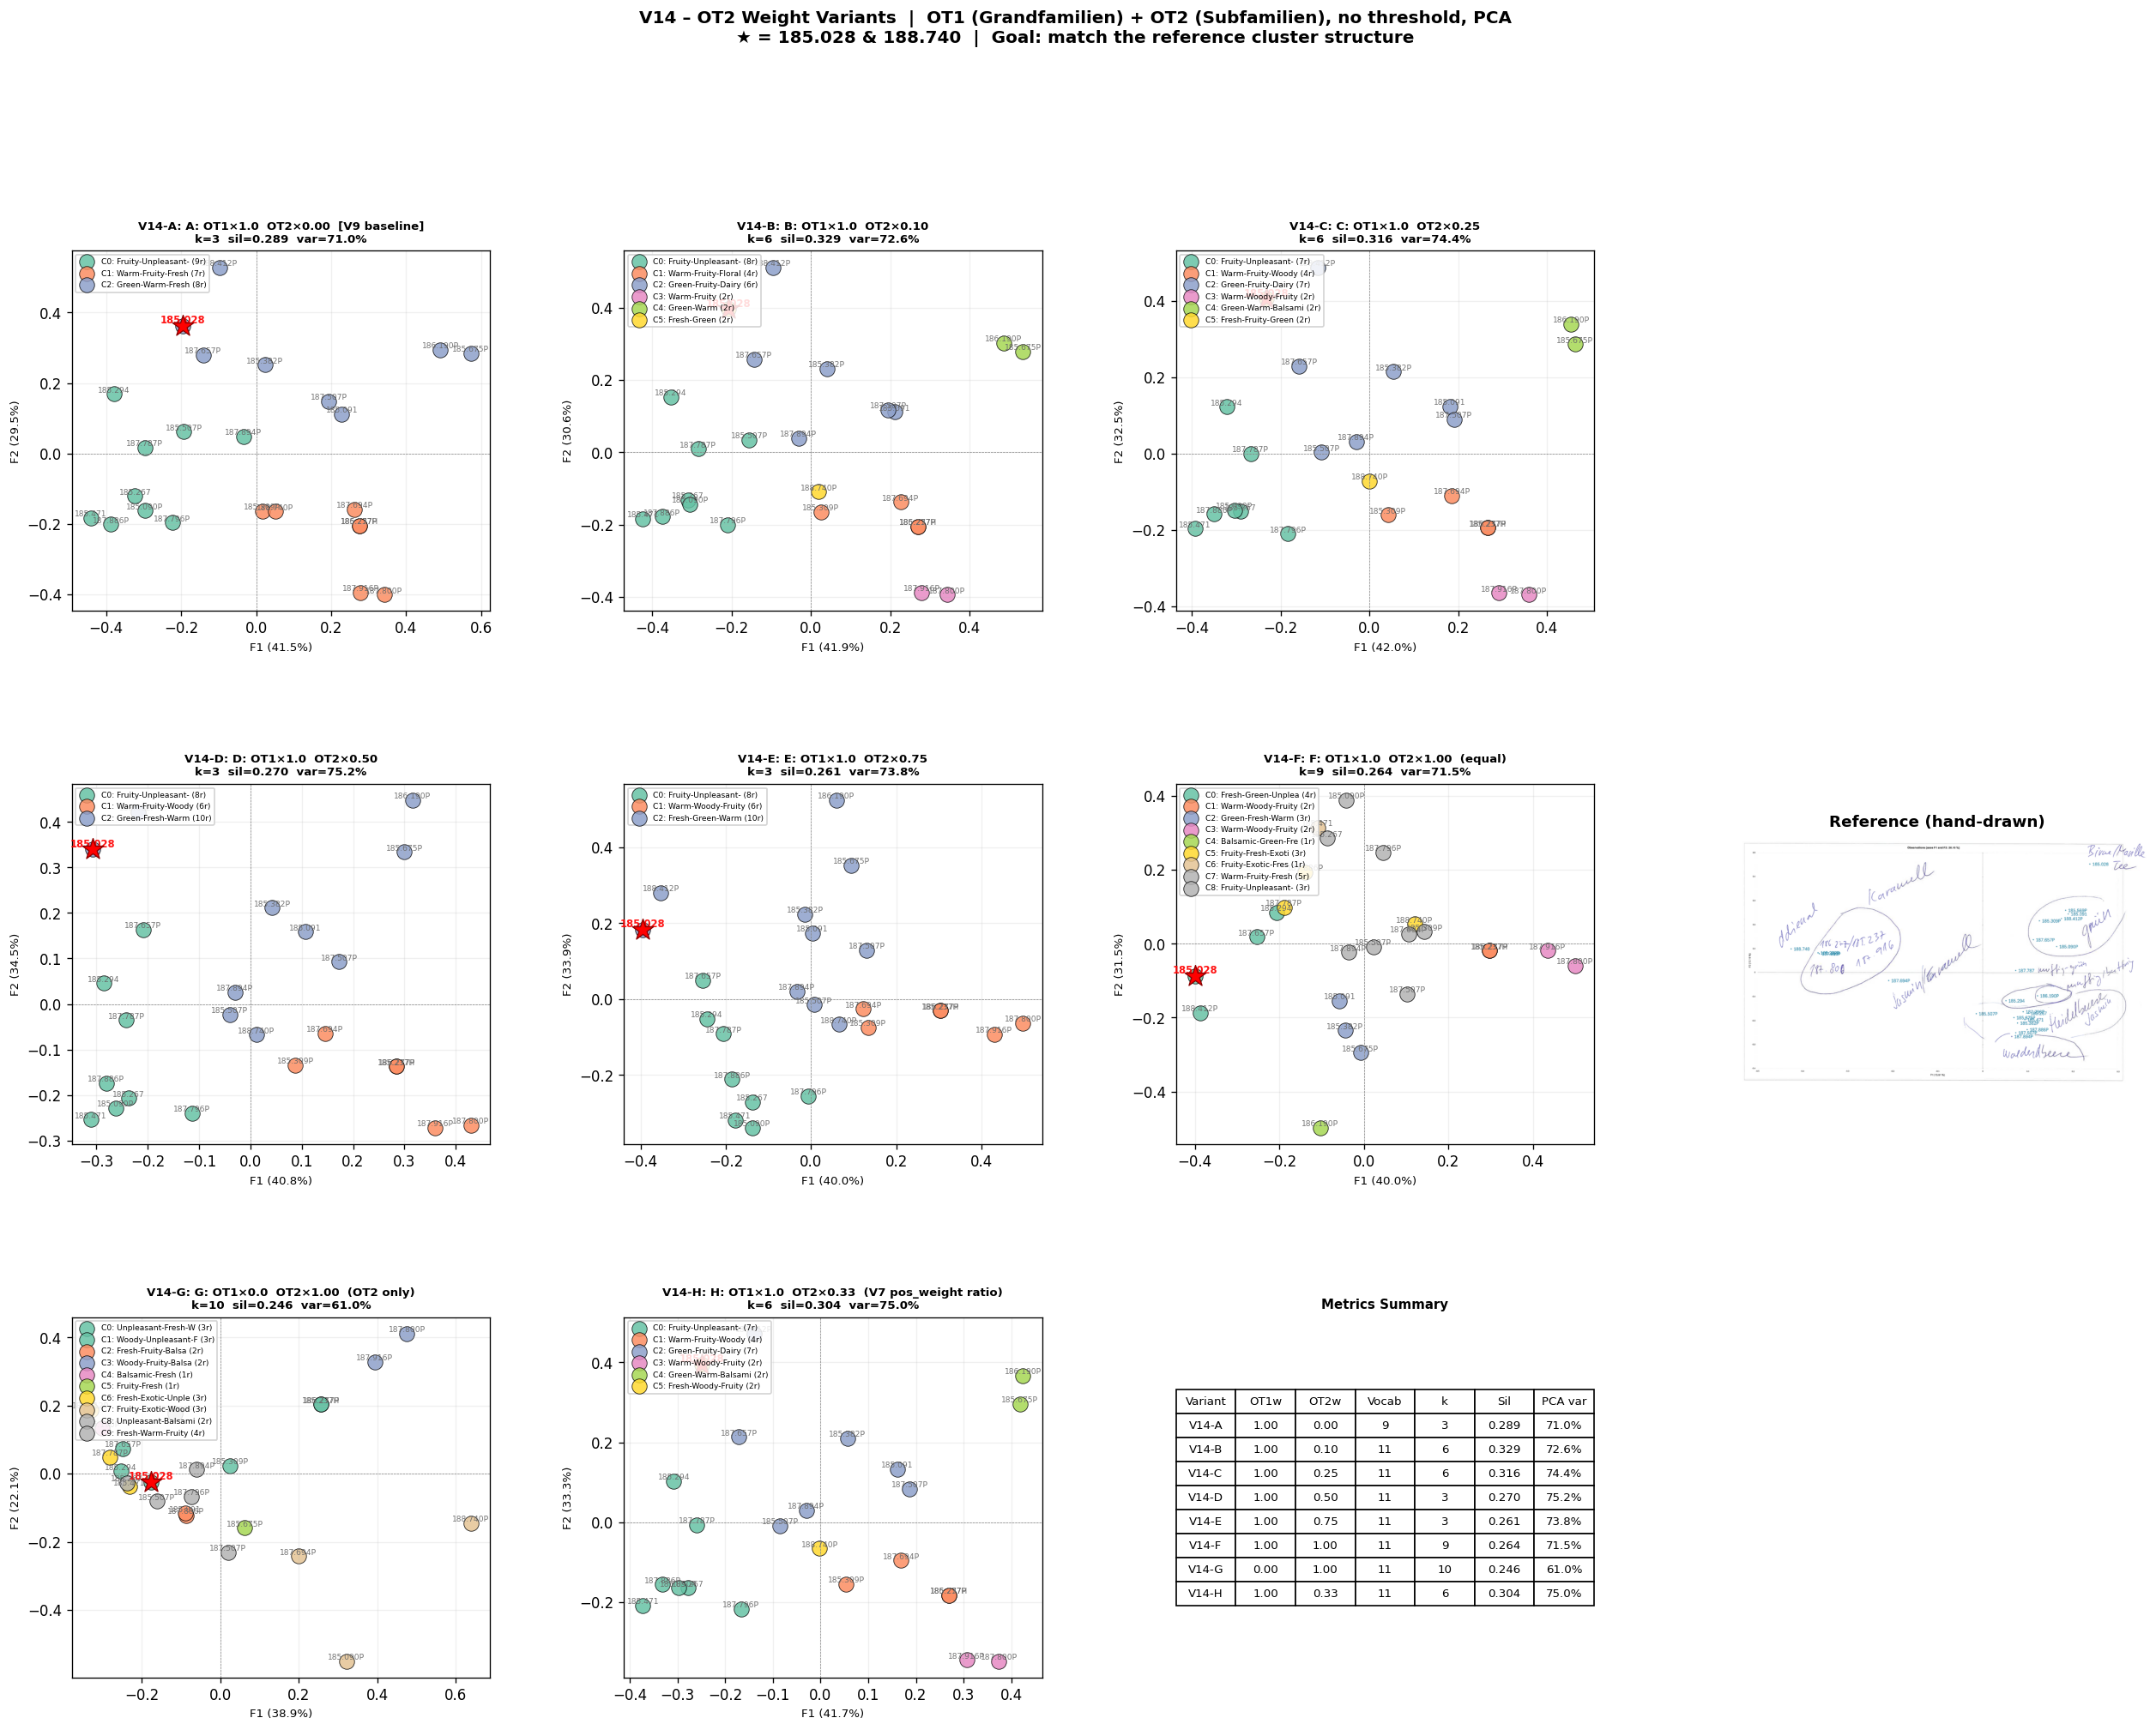

Saved → ../outputs/v14_ot2_weight_variants.png


In [7]:
def plot_pca_variant(ax, res, recipes, title=None):
    coords  = res['pca_coords']
    labels  = res['labels']
    cnames  = res['cnames']
    ve      = res['var_expl']
    unique_labels = sorted(set(labels))
    palette = plt.cm.Set2(np.linspace(0, 1, max(len(unique_labels), 8)))

    for j, cl in enumerate(unique_labels):
        mask = labels == cl
        pts  = coords[mask]
        c    = palette[j % len(palette)]
        ax.scatter(pts[:, 0], pts[:, 1], c=[c], s=110, alpha=0.85,
                   edgecolors='black', lw=0.5,
                   label=f'C{cl}: {cnames.get(cl, "")[:18]} ({mask.sum()}r)')

    for i, rec in enumerate(recipes):
        is_out = rec in OUTLIER_RECIPES
        ax.annotate(
            rec, (coords[i, 0], coords[i, 1]),
            fontsize=7 if is_out else 5.5,
            fontweight='bold' if is_out else 'normal',
            color='red' if is_out else 'dimgray',
            ha='center', va='bottom', alpha=0.92
        )
        if is_out:
            ax.scatter(coords[i, 0], coords[i, 1],
                       marker='*', s=240, c='red', zorder=5,
                       edgecolors='darkred', lw=0.8)

    ax.axhline(0, color='gray', lw=0.4, ls='--')
    ax.axvline(0, color='gray', lw=0.4, ls='--')
    ax.set_xlabel(f'F1 ({ve[0]:.1f}%)', fontsize=8)
    ax.set_ylabel(f'F2 ({ve[1]:.1f}%)', fontsize=8)
    t = title or res['label']
    ax.set_title(f'{t}\nk={res["k"]}  sil={res["score"]:.3f}  var={sum(ve):.1f}%',
                 fontsize=8, fontweight='bold')
    ax.legend(loc='upper left', fontsize=5.5, framealpha=0.85)
    ax.grid(True, alpha=0.18)


variant_ids = [v['id'] for v in VARIANTS]  # A B C D E F G H

# Layout: 3 rows × 3 cols; last cell = reference spanning rows 0-1 col 2
# Row 0: A B C | ref
# Row 1: D E F | ref
# Row 2: G H . |
fig = plt.figure(figsize=(26, 18))
gs  = gridspec.GridSpec(3, 4, figure=fig, wspace=0.32, hspace=0.48)

positions = [
    (0,0),(0,1),(0,2),   # A B C
    (1,0),(1,1),(1,2),   # D E F
    (2,0),(2,1),         # G H
]

for vid, (row, col) in zip(variant_ids, positions):
    ax = fig.add_subplot(gs[row, col])
    plot_pca_variant(ax, results[vid], recipes, title=f'V14-{vid}: {results[vid]["label"]}')

# Reference spans col 3, rows 0-2
ax_ref = fig.add_subplot(gs[:, 3])
if os.path.exists(REFERENCE_IMG):
    img = mpimg.imread(REFERENCE_IMG)
    ax_ref.imshow(img)
    ax_ref.set_title('Reference (hand-drawn)', fontsize=11, fontweight='bold')
else:
    ax_ref.text(0.5, 0.5, 'Reference image not found',
                ha='center', va='center', transform=ax_ref.transAxes, fontsize=12)
ax_ref.axis('off')

# Leave (2,2) and (2,3) as metrics summary
ax_metrics = fig.add_subplot(gs[2, 2])
ax_metrics.axis('off')
table_data = []
for vid in variant_ids:
    r = results[vid]
    ve = r['var_expl']
    table_data.append([
        f'V14-{vid}',
        f'{r["ot1"]:.2f}',
        f'{r["ot2"]:.2f}',
        str(r['vocab_size']),
        str(r['k']),
        f'{r["score"]:.3f}',
        f'{sum(ve):.1f}%',
    ])
tbl = ax_metrics.table(
    cellText=table_data,
    colLabels=['Variant', 'OT1w', 'OT2w', 'Vocab', 'k', 'Sil', 'PCA var'],
    loc='center', cellLoc='center'
)
tbl.auto_set_font_size(False)
tbl.set_fontsize(8)
tbl.scale(1.0, 1.4)
ax_metrics.set_title('Metrics Summary', fontsize=9, fontweight='bold')

fig.suptitle(
    'V14 – OT2 Weight Variants  |  OT1 (Grandfamilien) + OT2 (Subfamilien), no threshold, PCA\n'
    '★ = 185.028 & 188.740  |  Goal: match the reference cluster structure',
    fontsize=12, fontweight='bold', y=1.01
)

out_path = f'{OUTPUT_DIR}/v14_ot2_weight_variants.png'
plt.savefig(out_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved → {out_path}')

## 6. Silhouette Curve – Effect of OT2 Weight

WARNING clustering 24 points to 3 centroids: please provide at least 117 training points
WARNING clustering 24 points to 4 centroids: please provide at least 156 training points
WARNING clustering 24 points to 5 centroids: please provide at least 195 training points
WARNING clustering 24 points to 6 centroids: please provide at least 234 training points
WARNING clustering 24 points to 7 centroids: please provide at least 273 training points
WARNING clustering 24 points to 8 centroids: please provide at least 312 training points
WARNING clustering 24 points to 9 centroids: please provide at least 351 training points
WARNING clustering 24 points to 10 centroids: please provide at least 390 training points
WARNING clustering 24 points to 11 centroids: please provide at least 429 training points
WARNING clustering 24 points to 12 centroids: please provide at least 468 training points
WARNING clustering 24 points to 3 centroids: please provide at least 117 training points
WARNING clustering

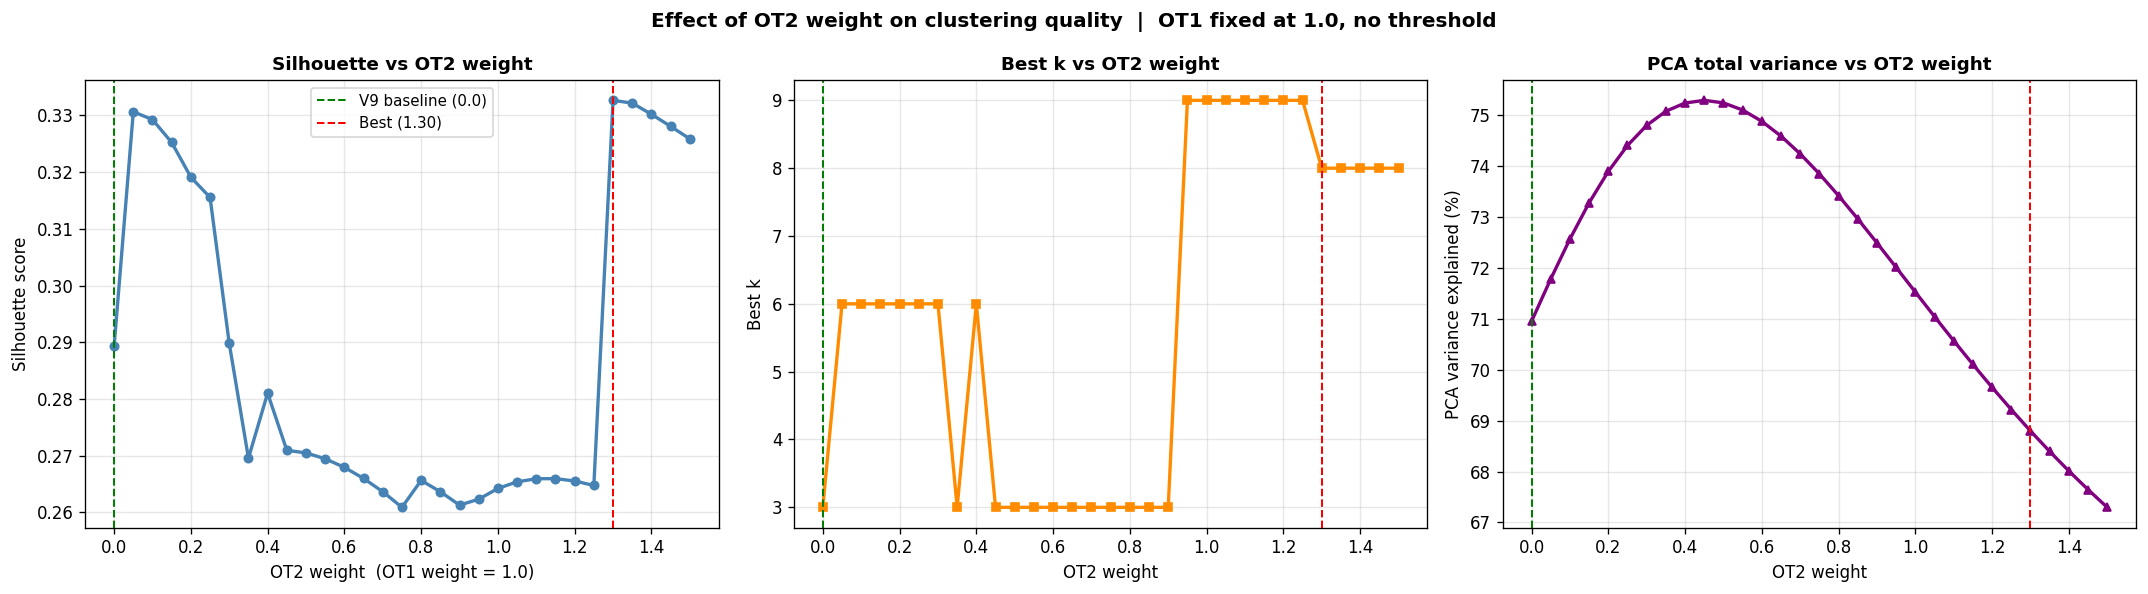

Saved → ../outputs/v14_ot2_weight_curve.png
Best OT2 weight by silhouette: 1.30  (score=0.3327)


In [8]:
# Fine-grained scan: OT2 weight from 0.0 to 1.5 in steps of 0.05
ot2_weights  = np.arange(0.0, 1.55, 0.05)
sil_scores   = []
best_ks      = []
total_vars   = []

for w2 in ot2_weights:
    fcw = [(OT1, 1.0)]
    if w2 > 0:
        fcw.append((OT2, float(w2)))
    _, vecs = build_recipe_vectors(df, recipes, fcw)
    labels, best_k, best_score = run_faiss_clustering(vecs)
    pca_obj = PCA(n_components=2)
    pca_obj.fit(vecs)
    sil_scores.append(best_score)
    best_ks.append(best_k)
    total_vars.append(pca_obj.explained_variance_ratio_.sum() * 100)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].plot(ot2_weights, sil_scores, 'o-', color='steelblue', lw=2, ms=5)
axes[0].axvline(0.0, color='green', ls='--', lw=1.2, label='V9 baseline (0.0)')
best_w = ot2_weights[np.argmax(sil_scores)]
axes[0].axvline(best_w, color='red', ls='--', lw=1.2, label=f'Best ({best_w:.2f})')
axes[0].set_xlabel('OT2 weight  (OT1 weight = 1.0)', fontsize=10)
axes[0].set_ylabel('Silhouette score', fontsize=10)
axes[0].set_title('Silhouette vs OT2 weight', fontsize=11, fontweight='bold')
axes[0].legend(fontsize=9)
axes[0].grid(True, alpha=0.3)

axes[1].plot(ot2_weights, best_ks, 's-', color='darkorange', lw=2, ms=5)
axes[1].axvline(0.0, color='green', ls='--', lw=1.2)
axes[1].axvline(best_w, color='red', ls='--', lw=1.2)
axes[1].set_xlabel('OT2 weight', fontsize=10)
axes[1].set_ylabel('Best k', fontsize=10)
axes[1].set_title('Best k vs OT2 weight', fontsize=11, fontweight='bold')
axes[1].yaxis.set_major_locator(plt.MaxNLocator(integer=True))
axes[1].grid(True, alpha=0.3)

axes[2].plot(ot2_weights, total_vars, '^-', color='purple', lw=2, ms=5)
axes[2].axvline(0.0, color='green', ls='--', lw=1.2)
axes[2].axvline(best_w, color='red', ls='--', lw=1.2)
axes[2].set_xlabel('OT2 weight', fontsize=10)
axes[2].set_ylabel('PCA variance explained (%)', fontsize=10)
axes[2].set_title('PCA total variance vs OT2 weight', fontsize=11, fontweight='bold')
axes[2].grid(True, alpha=0.3)

plt.suptitle('Effect of OT2 weight on clustering quality  |  OT1 fixed at 1.0, no threshold',
             fontsize=12, fontweight='bold')
plt.tight_layout()
curve_path = f'{OUTPUT_DIR}/v14_ot2_weight_curve.png'
plt.savefig(curve_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved → {curve_path}')
print(f'Best OT2 weight by silhouette: {best_w:.2f}  (score={max(sil_scores):.4f})')

## 7. Best OT2 Weight vs Reference (large comparison)

Best OT2 weight (fine scan): 1.30


WARNING clustering 24 points to 3 centroids: please provide at least 117 training points
WARNING clustering 24 points to 4 centroids: please provide at least 156 training points
WARNING clustering 24 points to 5 centroids: please provide at least 195 training points
WARNING clustering 24 points to 6 centroids: please provide at least 234 training points
WARNING clustering 24 points to 7 centroids: please provide at least 273 training points
WARNING clustering 24 points to 8 centroids: please provide at least 312 training points
WARNING clustering 24 points to 9 centroids: please provide at least 351 training points
WARNING clustering 24 points to 10 centroids: please provide at least 390 training points
WARNING clustering 24 points to 11 centroids: please provide at least 429 training points
WARNING clustering 24 points to 12 centroids: please provide at least 468 training points


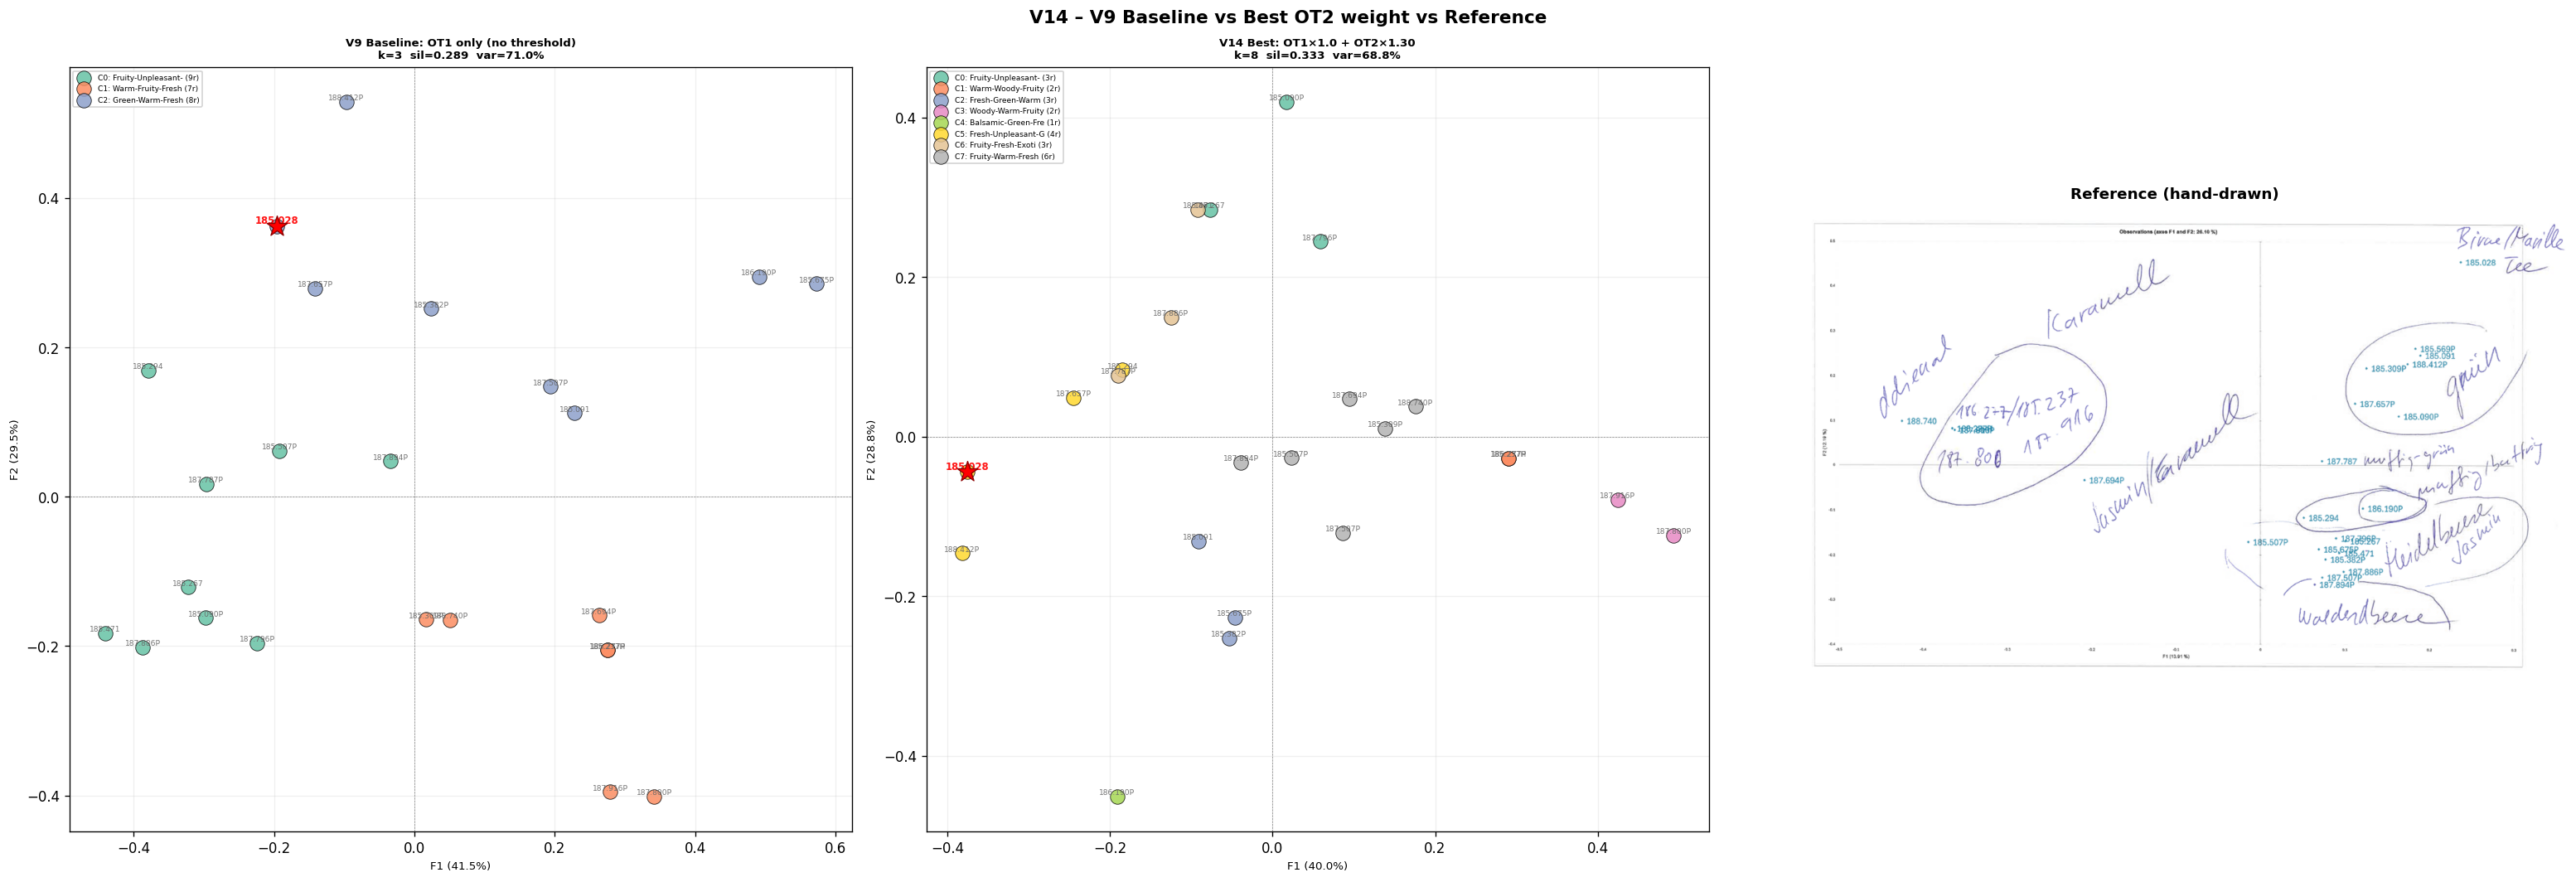

Saved → ../outputs/v14_best_vs_baseline_vs_reference.png


In [9]:
# Build the single best variant from the fine-grained scan
best_w2 = float(ot2_weights[np.argmax(sil_scores)])
print(f'Best OT2 weight (fine scan): {best_w2:.2f}')

fcw_best = [(OT1, 1.0)]
if best_w2 > 0:
    fcw_best.append((OT2, best_w2))

vocab_best, vecs_best = build_recipe_vectors(df, recipes, fcw_best)
labels_best, k_best, score_best = run_faiss_clustering(vecs_best)
cnames_best = generate_cluster_names(labels_best, vecs_best, vocab_best)
pca_best    = PCA(n_components=2)
coords_best = pca_best.fit_transform(vecs_best)
ve_best     = pca_best.explained_variance_ratio_ * 100

res_best = {
    'label'     : f'OT1×1.0 + OT2×{best_w2:.2f}  (fine-scan best)',
    'ot1': 1.0, 'ot2': best_w2,
    'vocab'     : vocab_best,
    'vecs'      : vecs_best,
    'labels'    : labels_best,
    'k'         : k_best,
    'score'     : score_best,
    'cnames'    : cnames_best,
    'pca_coords': coords_best,
    'var_expl'  : ve_best,
    'vocab_size': len(vocab_best),
}

fig, axes = plt.subplots(1, 3, figsize=(26, 9))

# Left: V9 baseline
plot_pca_variant(axes[0], results['A'], recipes,
                 title='V9 Baseline: OT1 only (no threshold)')

# Middle: best from fine scan
plot_pca_variant(axes[1], res_best, recipes,
                 title=f'V14 Best: OT1×1.0 + OT2×{best_w2:.2f}')

# Right: reference
if os.path.exists(REFERENCE_IMG):
    img = mpimg.imread(REFERENCE_IMG)
    axes[2].imshow(img)
    axes[2].set_title('Reference (hand-drawn)', fontsize=11, fontweight='bold')
else:
    axes[2].text(0.5, 0.5, 'Reference not found',
                 ha='center', va='center', transform=axes[2].transAxes)
axes[2].axis('off')

plt.suptitle('V14 – V9 Baseline vs Best OT2 weight vs Reference',
             fontsize=13, fontweight='bold')
plt.tight_layout()
best_path = f'{OUTPUT_DIR}/v14_best_vs_baseline_vs_reference.png'
plt.savefig(best_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved → {best_path}')

## 8. Metrics Summary

In [10]:
print(f'{"Variant":<45} {"OT1w":>5} {"OT2w":>5} {"Vocab":>6} '
      f'{"k":>4} {"Silhouette":>12} {"PCA total":>10}')
print('-' * 95)
for vid in variant_ids:
    r  = results[vid]
    ve = r['var_expl']
    baseline = ' ← V9 baseline' if vid == 'A' else ''
    print(f'{r["label"]:<45} {r["ot1"]:>5.2f} {r["ot2"]:>5.2f} {r["vocab_size"]:>6} '
          f'{r["k"]:>4} {r["score"]:>12.4f} {sum(ve):>9.1f}%{baseline}')

print()
print(f'Fine-scan best OT2 weight: {best_w2:.2f}  (silhouette={max(sil_scores):.4f})')
print()
print('Outlier recipe positions:')
print(f'{"Variant":<8} ', end='')
for rec in OUTLIER_RECIPES:
    print(f'{rec:>34}', end='')
print()
for vid in variant_ids:
    r      = results[vid]
    coords = r['pca_coords']
    labels = r['labels']
    cnames = r['cnames']
    print(f'V14-{vid:<4} ', end='')
    for rec in OUTLIER_RECIPES:
        if rec in recipes:
            idx = recipes.index(rec)
            cl  = labels[idx]
            pos = coords[idx]
            print(f'  C{cl}({cnames[cl][:10]}) F1={pos[0]:+.2f} F2={pos[1]:+.2f}', end='')
    print()

Variant                                        OT1w  OT2w  Vocab    k   Silhouette  PCA total
-----------------------------------------------------------------------------------------------
A: OT1×1.0  OT2×0.00  [V9 baseline]            1.00  0.00      9    3       0.2893      71.0% ← V9 baseline
B: OT1×1.0  OT2×0.10                           1.00  0.10     11    6       0.3293      72.6%
C: OT1×1.0  OT2×0.25                           1.00  0.25     11    6       0.3155      74.4%
D: OT1×1.0  OT2×0.50                           1.00  0.50     11    3       0.2705      75.2%
E: OT1×1.0  OT2×0.75                           1.00  0.75     11    3       0.2609      73.8%
F: OT1×1.0  OT2×1.00  (equal)                  1.00  1.00     11    9       0.2642      71.5%
G: OT1×0.0  OT2×1.00  (OT2 only)               0.00  1.00     11   10       0.2463      61.0%
H: OT1×1.0  OT2×0.33  (V7 pos_weight ratio)    1.00  0.33     11    6       0.3039      75.0%

Fine-scan best OT2 weight: 1.30  (silhouett

## 9. Key Findings & Conclusions

### What we tested
Adding OT2 (subfamilies) alongside OT1 (Grandfamilien) with progressively increasing weight,
keeping no-threshold (pure Totalmenge), to see if richer features improve cluster separation.

### What to look for
A good variant should:
- Separate the **Karamell/Süß** group (upper-left in reference)
- Separate the **Heidelbeere/Jasmin/Waldbeer** group (lower-right)
- Keep **185.028** (Birne/Marille/Tee) isolated upper-right
- Keep **188.740** (Addierand) isolated left

### Expected outcomes
- Very low OT2 weight (0.0–0.1): same as V9, no improvement
- Moderate OT2 weight (0.25–0.5): likely best — adds sub-family nuance without overpowering OT1 signal
- High OT2 weight (≥0.75): OT2 starts dominating; may fragment clusters or introduce noise
- OT2 only (G): control — pure subfamilien without Grandfamilien anchor

### Next steps
If the best OT2 weight improves visual match, consider also testing OT3 at an even lower weight.
If no OT2 weight helps, the feature space limit has been reached and the model is as good as it
can get with this dataset size (24 recipes).